# Estimated Phytoplankton Size

In [1]:
# CIndRA notebook display standard
import matplotlib as mpl

mpl.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 15,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 13,
    'figure.dpi': 100,
    'savefig.dpi': 300,
})

```{glue:figure} average_map
:scale: 50%
:align: center
```

```{glue:figure} average_timeseries
:scale: 50%
:align: center
```

**Figure. Estimated Median Phytoplankton Size from satellite.**  The map (top) shows the change in the estimated median phytoplankton size (μm equivalent spherical diameter, ESD) in the vicinity of Palau over the period 1998-2023 derived from satellite remotely sensed sea surface temperature and ocean color data.  The grey line is the Palau EEZ.  The line plot (bottom) shows the change in the estimated median phytoplankton size  (μm ESD) averaged over the area within the top plot.  The black line represents the trend, which is not statistically significant (p > 0.05).

In [2]:
import json
import os.path as op
import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import cartopy.crs as ccrs
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

try:
    from myst_nb import glue
except ImportError:
    def glue(name, value, display=False):
        return value

# Locate CIndRA independently of the directory from which Jupyter was started.
root_candidates = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
repo_root = next((p for p in root_candidates if (p / "functions/data_downloaders.py").is_file()), None)
if repo_root is None:
    raise FileNotFoundError("Could not locate the CIndRA repository root.")

indicators_setup_dir = repo_root.parents[1] / "indicators_setup"
if not indicators_setup_dir.is_dir():
    raise FileNotFoundError(f"Shared indicators package not found: {indicators_setup_dir}")
sys.path.insert(0, str(indicators_setup_dir))
sys.path.insert(0, str(repo_root / "functions"))

from ind_setup.plotting_int import plot_timeseries_interactive, plot_oni_index_th
from ind_setup.plotting import (
    plot_base_map, plot_map_subplots, add_oni_cat, plot_bar_probs, fontsize,
)
from data_downloaders import download_ERDDAP_data, download_oni_index
from ocean import process_trend_with_nan
from sst import polygon_mask

# National-site configuration shared with the other indicator families.
site_config_file = repo_root / "data/sites/palau.json"
site_config = json.loads(site_config_file.read_text())
site_name = site_config["site_name"]
country = site_config.get("country", site_name)
site_lon = float(site_config["site_lon"])
site_lat = float(site_config["site_lat"])
loc = [site_lat, site_lon]

data_dir = repo_root / "data"
biochemistry_data_dir = data_dir / "biochemistry"
fig_dir = repo_root / "matrix_cc/figures"
biochemistry_data_dir.mkdir(parents=True, exist_ok=True)
fig_dir.mkdir(parents=True, exist_ok=True)
path_data = biochemistry_data_dir
path_figs = fig_dir

eez_file = data_dir / "Palau_EEZ/pw_eez_pol_april2022.shp"
shp_eez = gpd.read_file(eez_file).to_crs(4326)
xmin, ymin, xmax, ymax = shp_eez.total_bounds
lon_range = [float(xmin), float(xmax)]
lat_range = [float(ymin), float(ymax)]

def mask_dataset_to_eez(dataset):
    """Mask a latitude/longitude dataset to cell centres inside the selected EEZ."""
    geometry = shp_eez.geometry.unary_union
    mask = polygon_mask(geometry, np.asarray(dataset.longitude), np.asarray(dataset.latitude)).rename(
        {"lon": "longitude", "lat": "latitude"}
    )
    return dataset.where(mask)

print(f"Site: {site_name} ({site_lat:.3f}°N, {site_lon:.3f}°E)")
print(f"Biochemistry data: {biochemistry_data_dir}")


Site: Palau (7.340°N, 134.620°E)
Biochemistry data: /Users/laurac/Library/Mobile Documents/com~apple~CloudDocs/Projects/CC_indicators/PICCM/CIndRA/data/biochemistry


## Setup

Define area of interest

In [3]:
# Area of interest derived from the configured EEZ
print(f"Longitude: {lon_range}; latitude: {lat_range}")


Longitude: [129.508805, 136.994722]; latitude: [1.621407, 11.558725]


EEZ shapefile

In [4]:
shp_f = eez_file
print(f"EEZ: {shp_f}")

EEZ: /Users/laurac/Library/Mobile Documents/com~apple~CloudDocs/Projects/CC_indicators/PICCM/CIndRA/data/Palau_EEZ/pw_eez_pol_april2022.shp


## Download Data

DATASET: https://oceanwatch.pifsc.noaa.gov/erddap/info/md50_exp/index.html

In [5]:
update_data = False
path_data = biochemistry_data_dir
path_figs = fig_dir

In [6]:
base_url = 'https://oceanwatch.pifsc.noaa.gov/erddap/griddap/md50_exp.csv'
dataset_id = 'MD50'

if update_data:
    date_ini = '1998-01-01T00:00:00Z'
    date_end = '2024-12-01T00:00:00Z'
    data = download_ERDDAP_data(base_url, dataset_id, date_ini, date_end, lon_range, lat_range)
    data_xr = data.set_index(['latitude', 'longitude', 'time']).to_xarray()
    data_xr['time'] = pd.to_datetime(data_xr.time)
    data_xr = data_xr.coarsen(longitude=2, latitude=2, boundary = 'pad').mean()
    data_xr.to_netcdf(path_data / f'griddap_{dataset_id}.nc')
else:
    data_xr = xr.open_dataset(path_data / f'griddap_{dataset_id}.nc')

if 'depth' in data_xr.dims:
    data_xr = data_xr.isel(depth=0, drop=True)
data_xr = mask_dataset_to_eez(data_xr)
print(f"{dataset_id}: {str(data_xr.time.min().values)[:10]} to {str(data_xr.time.max().values)[:10]}")


MD50: 1998-01-01 to 2024-12-01


## Analysis

### Plotting

#### Average

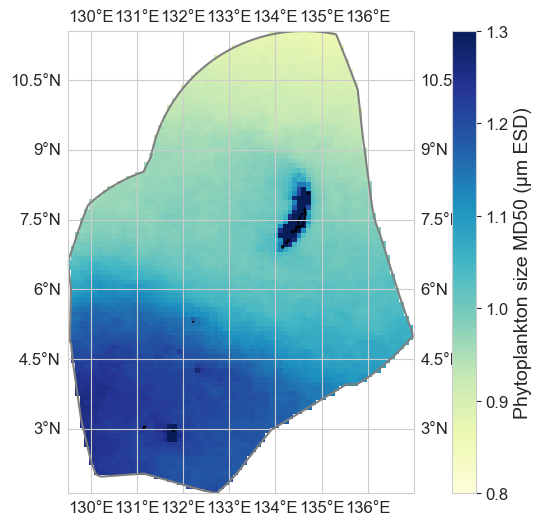

In [7]:
fig, ax = plot_base_map(shp_eez = shp_eez, figsize = [10, 6])
im = ax.pcolor(data_xr.longitude, data_xr.latitude, data_xr.mean(dim='time')[dataset_id], transform=ccrs.PlateCarree(), 
                cmap = 'YlGnBu', vmin = 0.8, vmax = 1.3)
ax.set_extent([lon_range[0], lon_range[1], lat_range[0], lat_range[1]], crs=ccrs.PlateCarree())
plt.colorbar(im, ax=ax, label='Phytoplankton size MD50 (µm ESD)')
glue("average_map", fig, display=False)
plt.savefig(op.join(path_figs, 'F16_phytoplankton_mean_map.png'), dpi=300, bbox_inches='tight')


#### Change

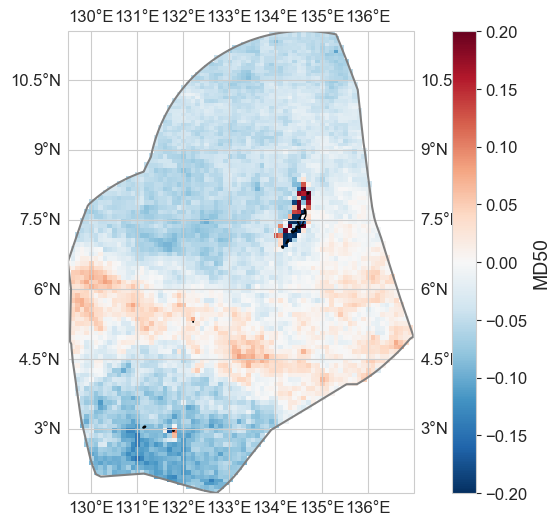

In [8]:
trend_m, _, _, _, _ = process_trend_with_nan(data_xr[dataset_id])

fig, ax = plot_base_map(shp_eez = shp_eez, figsize = [10, 6])
im = ax.pcolor(data_xr.longitude, data_xr.latitude, 
               trend_m,
                transform=ccrs.PlateCarree(), 
                cmap = 'RdBu_r', 
                vmin = -.2,
                vmax = .2,
                )
ax.set_extent([lon_range[0], lon_range[1], lat_range[0], lat_range[1]], crs=ccrs.PlateCarree())
plt.colorbar(im, ax=ax, label=  dataset_id)
plt.savefig(op.join(path_figs, 'F16_phytoplankton_mean_map_trend.png'), dpi=300, bbox_inches='tight')


#### Seasonal average

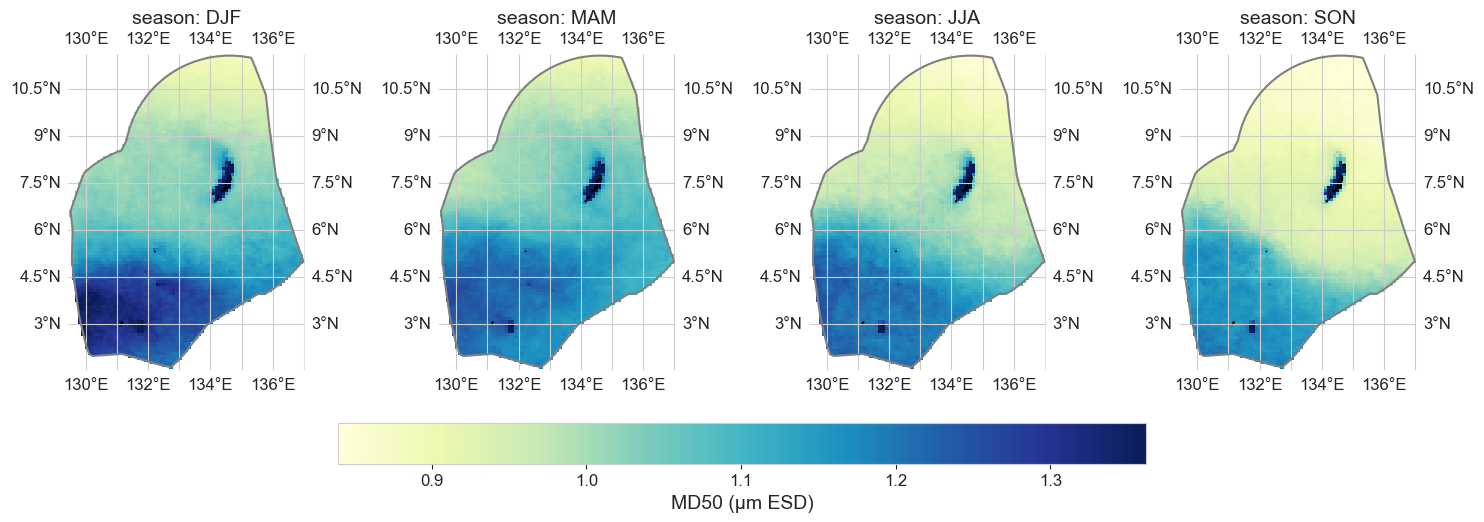

In [9]:
data_month = data_xr.groupby('time.season').mean().sel(season = ['DJF', 'MAM', 'JJA', 'SON'])
im = plot_map_subplots(data_month, dataset_id, shp_eez = shp_eez, cmap = 'YlGnBu', 
                  vmin = np.nanpercentile(data_month.min(dim = 'season')[dataset_id], 1), 
                  vmax = np.nanpercentile(data_month.max(dim = 'season')[dataset_id], 99),
                  figsize = (15,11), sub_plot = [1, 4], cbar_pad = 0.05, cbar = 1)

#### Seasonal anomaly

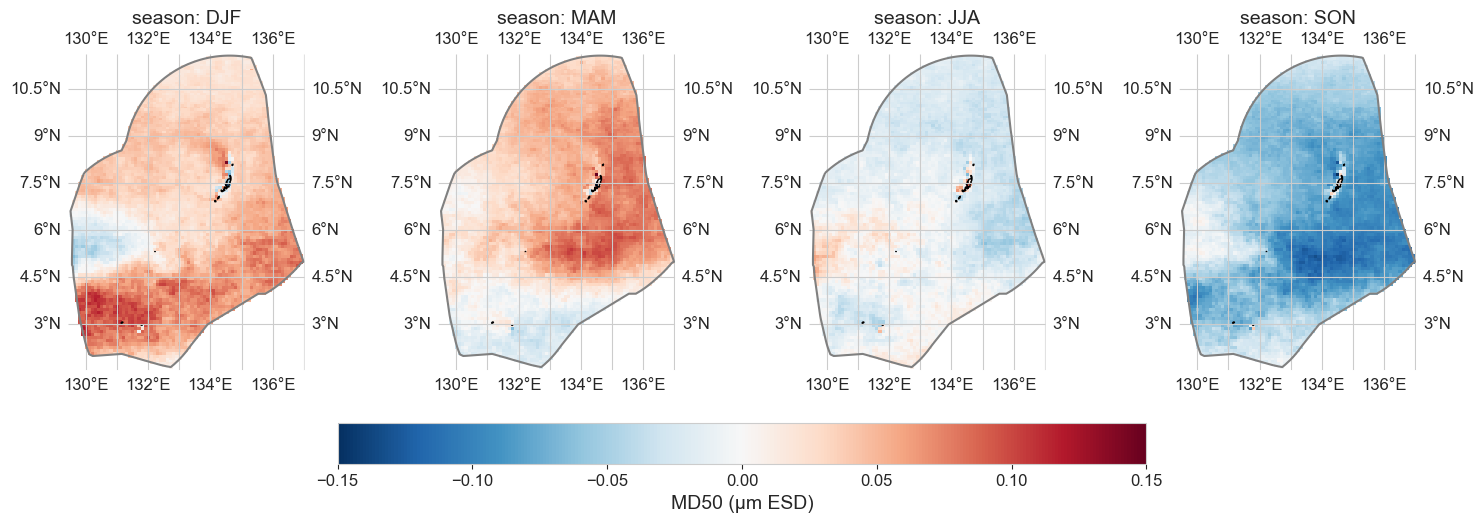

In [10]:
data_month = data_xr.groupby('time.season').mean().sel(season = ['DJF', 'MAM', 'JJA', 'SON']) - data_xr.mean(dim='time')
im = plot_map_subplots(data_month, dataset_id, shp_eez = shp_eez, 
                  cmap = 'RdBu_r', vmin=-.15, vmax=.15,
                  figsize = (15,11), sub_plot = [1, 4], cbar_pad = 0.05,
                  cbar = 1)

#### Annual average

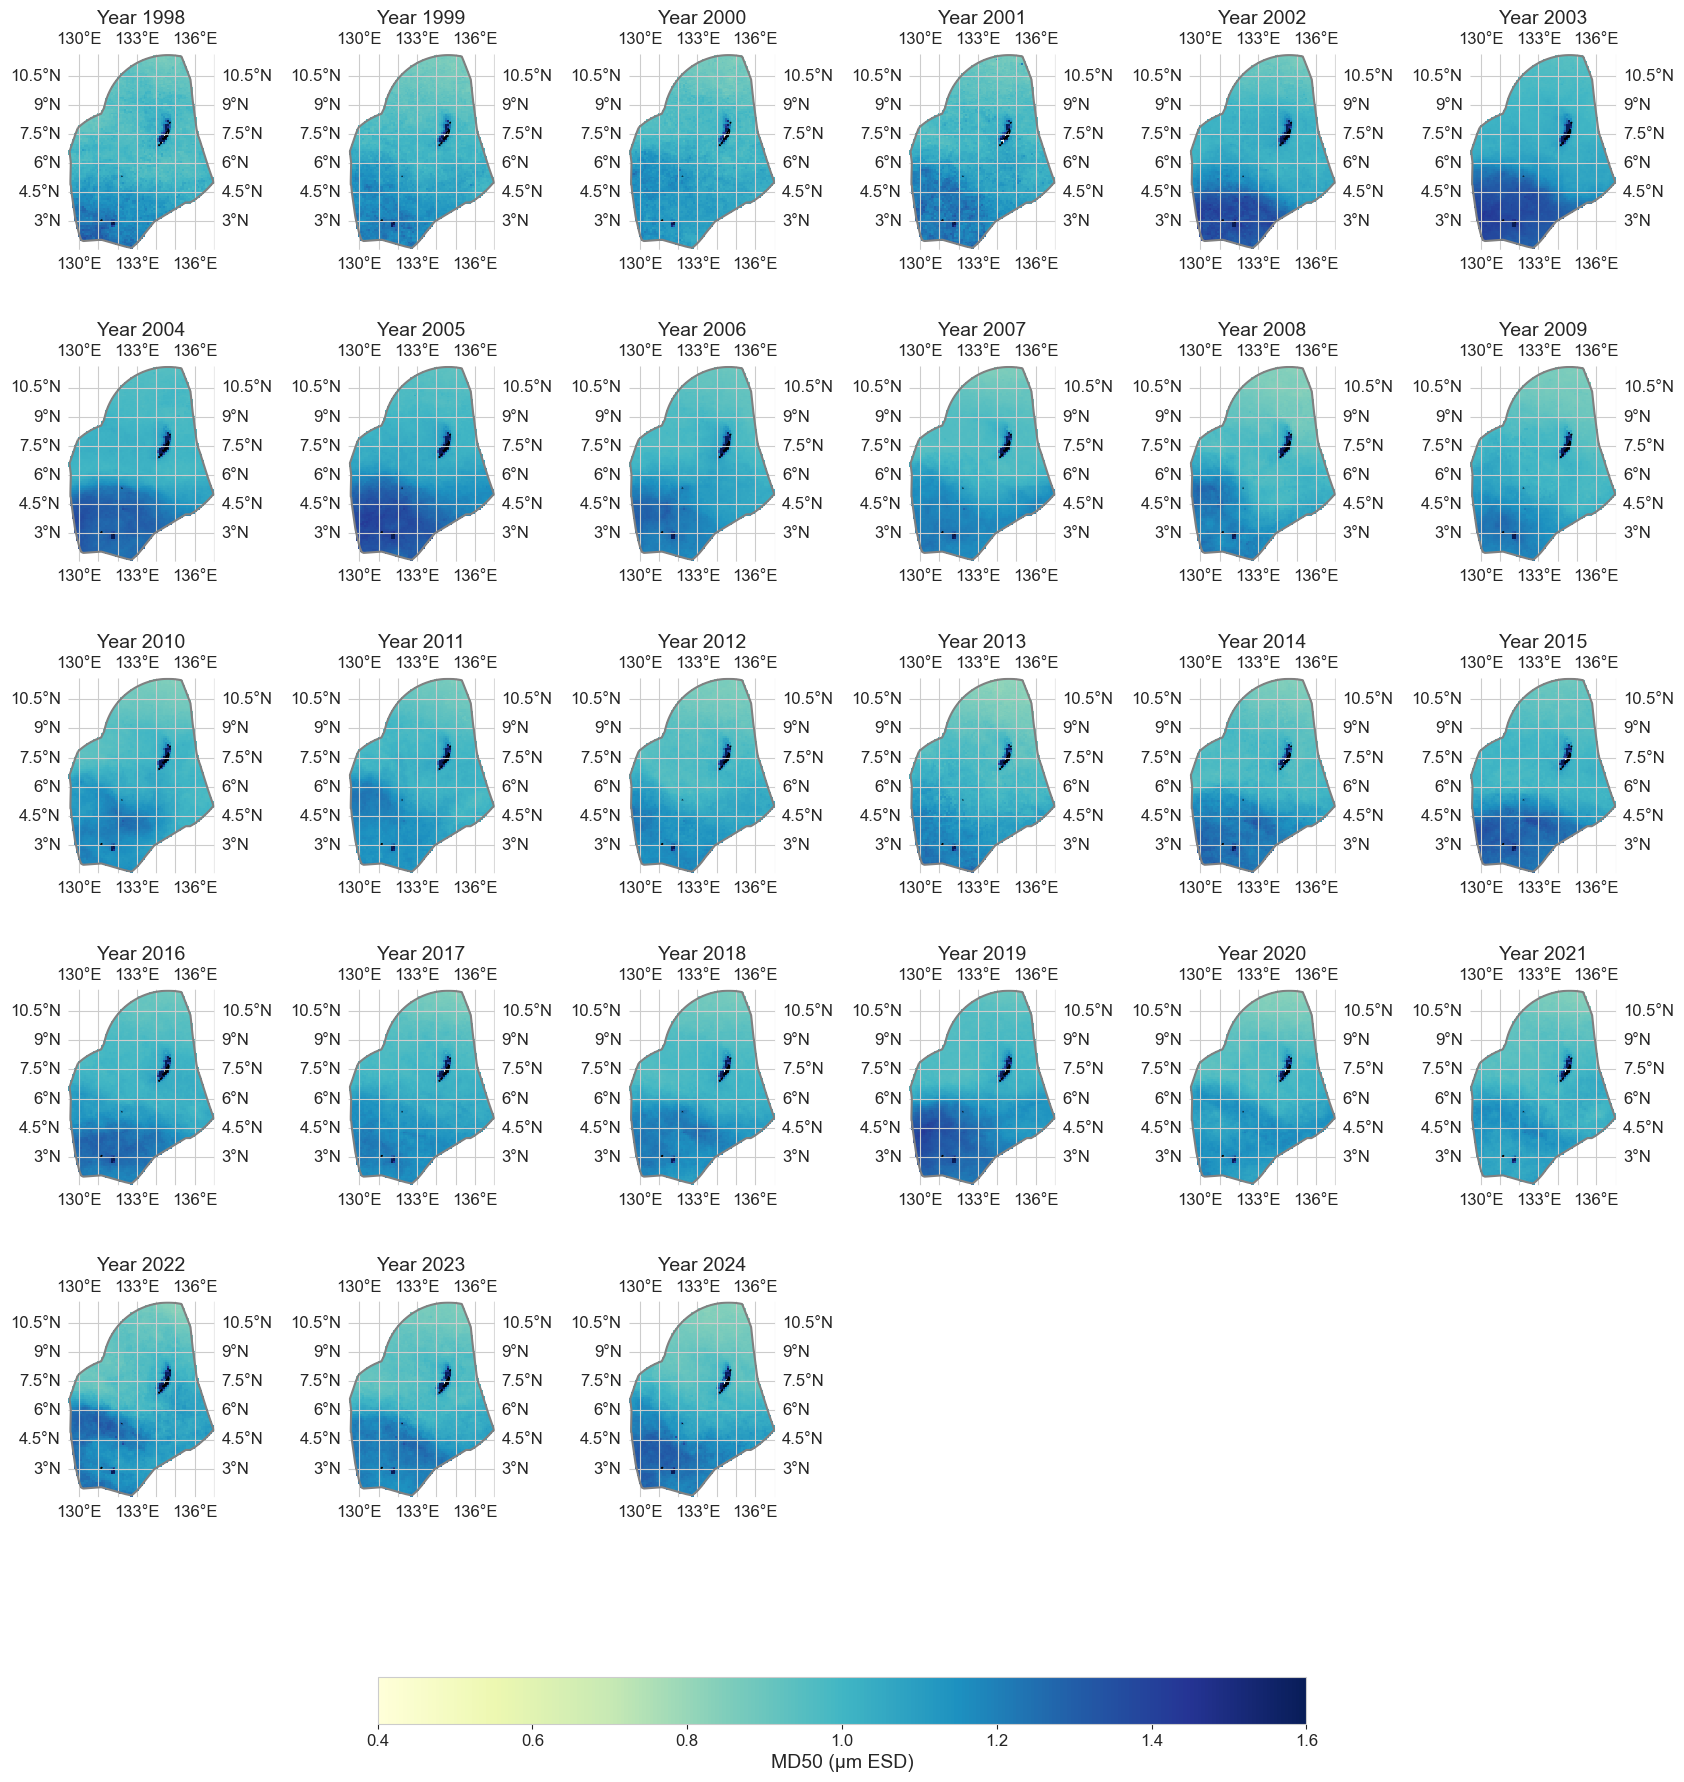

In [11]:
data_y = data_xr.resample(time='1YE').mean()
fig = plot_map_subplots(data_y, 'MD50', shp_eez = shp_eez, cmap = 'YlGnBu', vmin = 0.4, vmax = 1.6, cbar = 1)

#### Annual anomaly

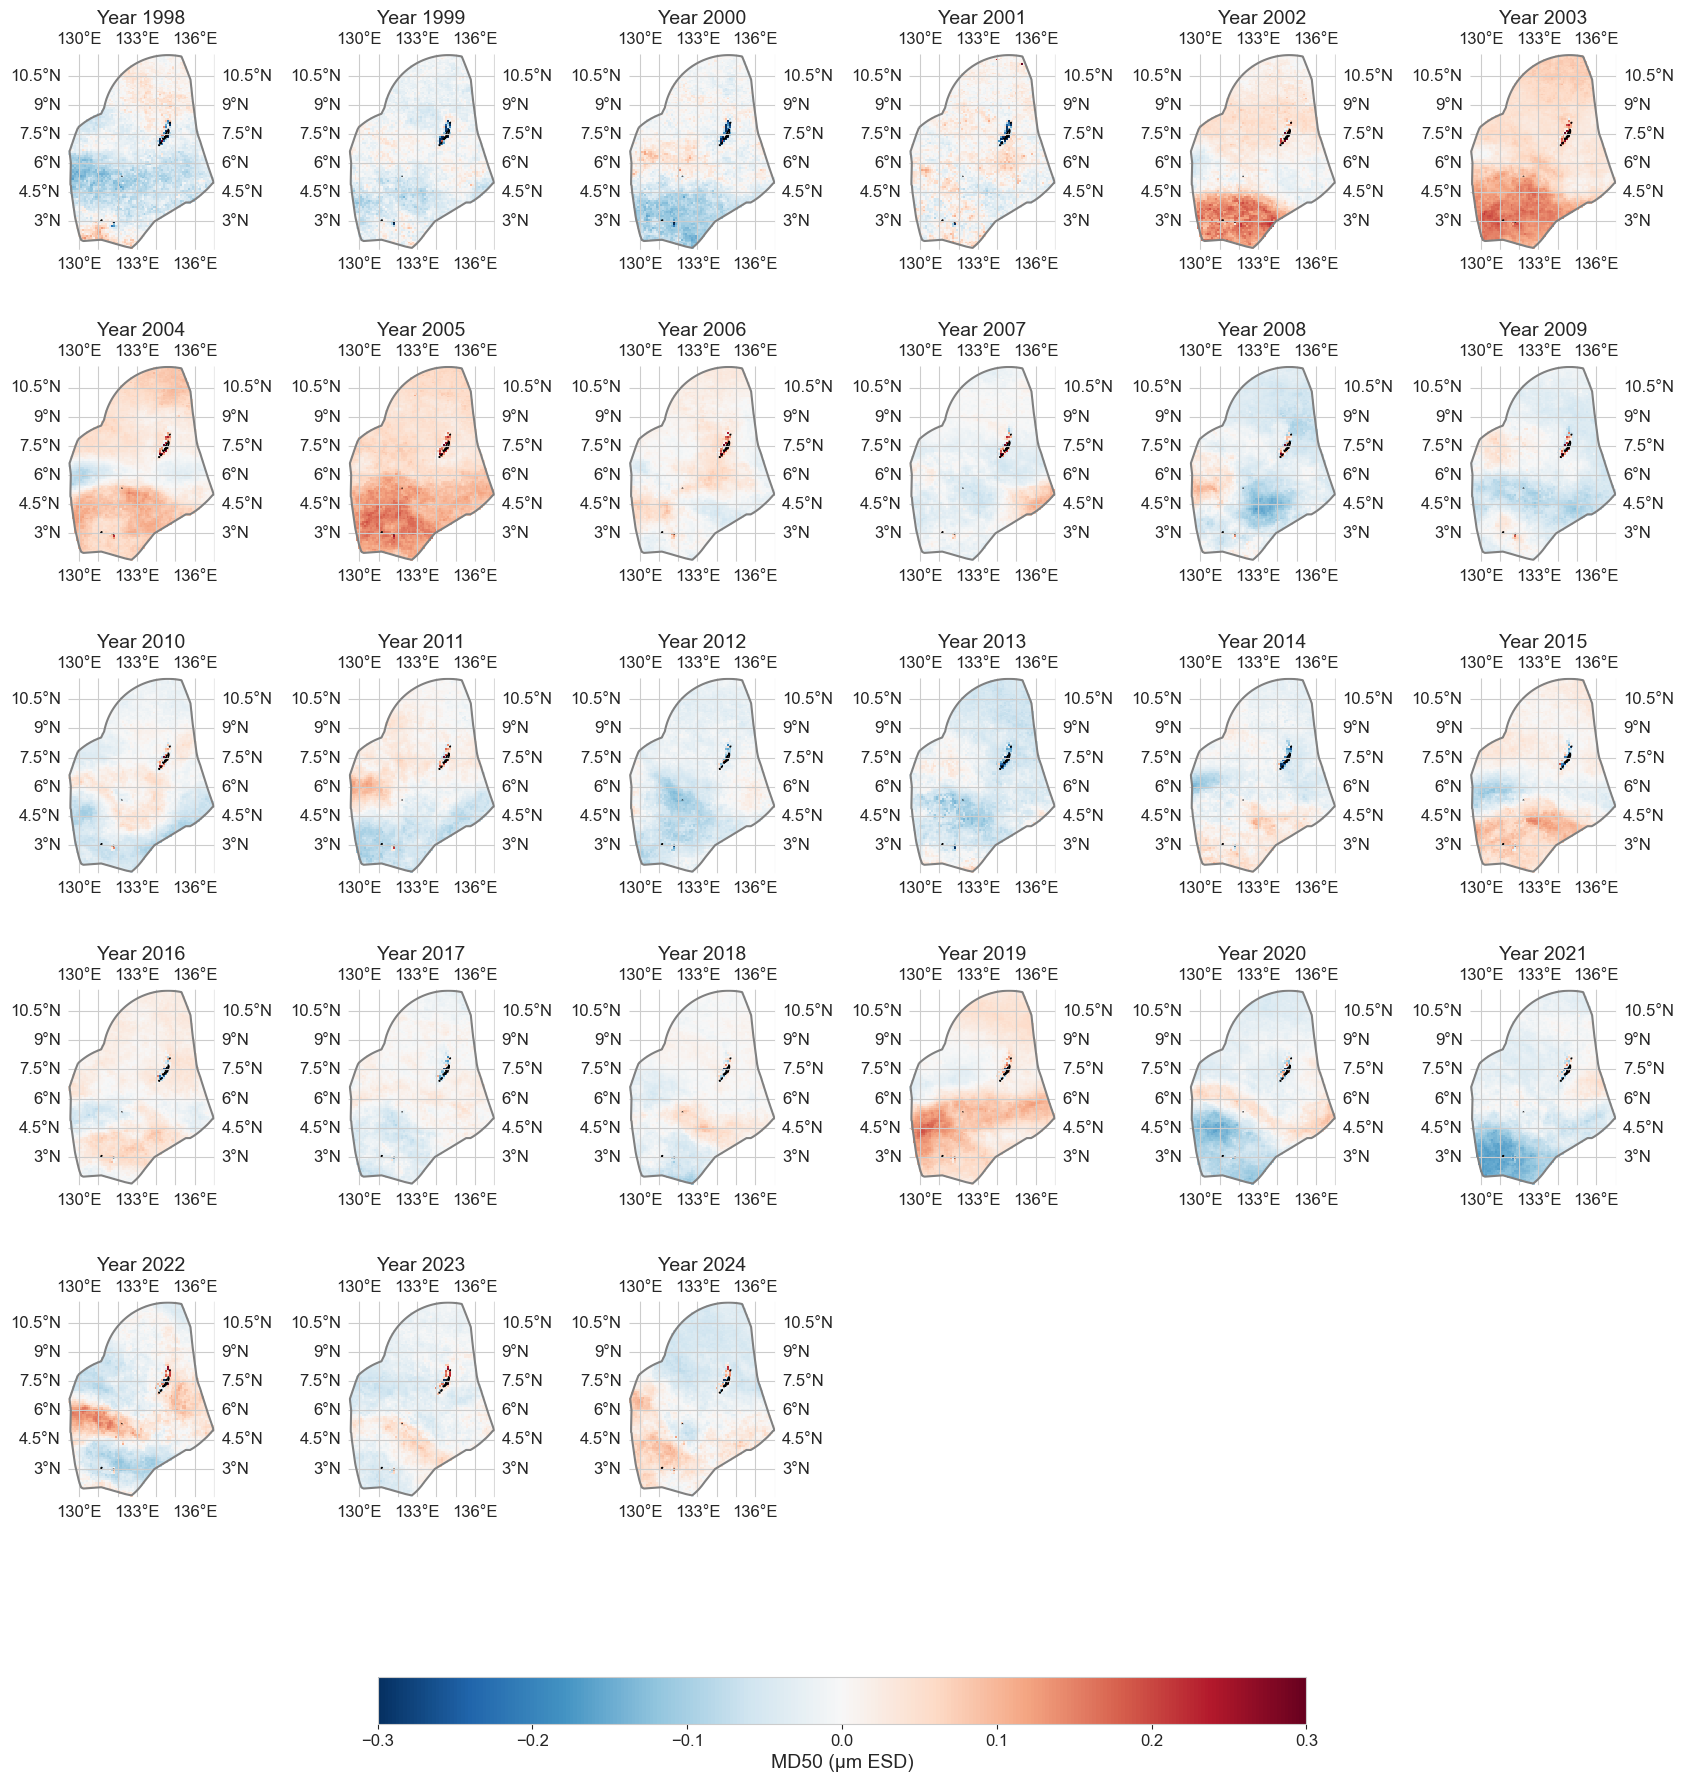

In [12]:
data_an = data_y - data_xr.mean(dim='time')
fig = plot_map_subplots(data_an, dataset_id, shp_eez = shp_eez, cmap='RdBu_r', vmin=-.3, vmax=.3, cbar = 1)

#### Average over area

In [13]:
dict_plot = [{'data' : data_xr.mean(dim = ['longitude', 'latitude']).to_dataframe(), 
              'var' : dataset_id, 'ax' : 1, 'label' : 'Median Phytoplankton Size - MEAN AREA'},]

In [14]:
fig, trend = plot_timeseries_interactive(dict_plot, trendline=True, return_trend=True, scatter_dict = None, figsize = (25, 12), 
                                 label_yaxes = 'Phytoplankton MD50 (µm ESD)');
fig.write_html(op.join(path_figs, 'F16_phytoplankton_mean_trend.html'), include_plotlyjs="cdn")
fig.write_image(op.join(path_figs, 'F16_phytoplankton_mean_trend.png'), width=1200, height=600,)

#### Seasonal variability

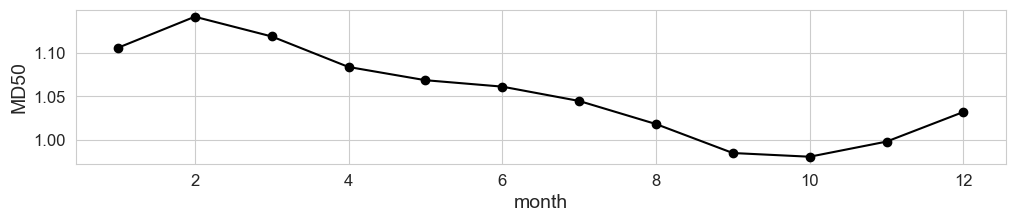

In [15]:
fig, ax = plt.subplots(figsize=(12,2))
data_xr.mean(dim = ['longitude', 'latitude']).groupby('time.month').mean()[dataset_id].plot(ax = ax, marker = 'o', color = 'k')

In [16]:
d_p = data_xr.mean(dim = ['longitude', 'latitude']).to_dataframe()

#### Timeseries at a given point

In [17]:
# Point comes from the selected national site configuration.
dict_plot = [{'data' : data_xr.sel(longitude=loc[1], latitude=loc[0], method='nearest').to_dataframe(), 
              'var' : dataset_id, 'ax' : 1, 'label' : f'Median Phytoplankton Size at [{loc[0]}, {loc[1]}]'},]

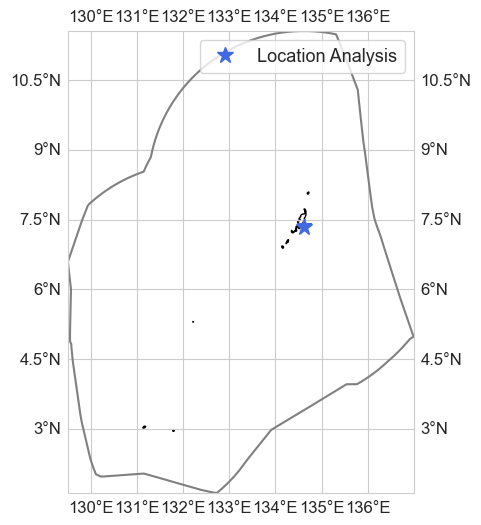

In [18]:
fig, ax = plot_base_map(shp_eez = shp_eez, figsize = [10, 6])
ax.set_extent([lon_range[0], lon_range[1], lat_range[0], lat_range[1]], crs=ccrs.PlateCarree())
ax.plot(loc[1], loc[0], '*', markersize = 12, color = 'royalblue', transform=ccrs.PlateCarree(), label = 'Location Analysis')
ax.legend()

In [19]:
fig = plot_timeseries_interactive(dict_plot, trendline=True, scatter_dict = None, figsize = (25, 12),
                                 label_yaxes = 'Phytoplankton MD50 (µm ESD)');

### ONI index analysis

In [20]:
oni_cache = op.join(path_data, 'oni_index.pkl')
p_data = 'https://psl.noaa.gov/data/correlation/oni.data'
if update_data or not op.exists(oni_cache):
    df1 = download_oni_index(p_data)
    df1.to_pickle(oni_cache)
else:
    df1 = pd.read_pickle(oni_cache)

In [21]:
lims = [-.5, .5]
plot_oni_index_th(df1, lims = lims)

Group by ONI category

In [22]:
df1 = add_oni_cat(df1, lims = lims)
df1['ONI'] = df1['oni_cat']
data_xr['ONI'] = (('time'), df1.iloc[np.intersect1d(data_xr.time, df1.index, return_indices=True)[2]].ONI.values)
data_xr['ONI_cat'] = (('time'), np.where(data_xr.ONI < lims[0], -1, np.where(data_xr.ONI > lims[1], 1, 0)))
data_oni = data_xr.groupby('ONI_cat').mean()

#### Average

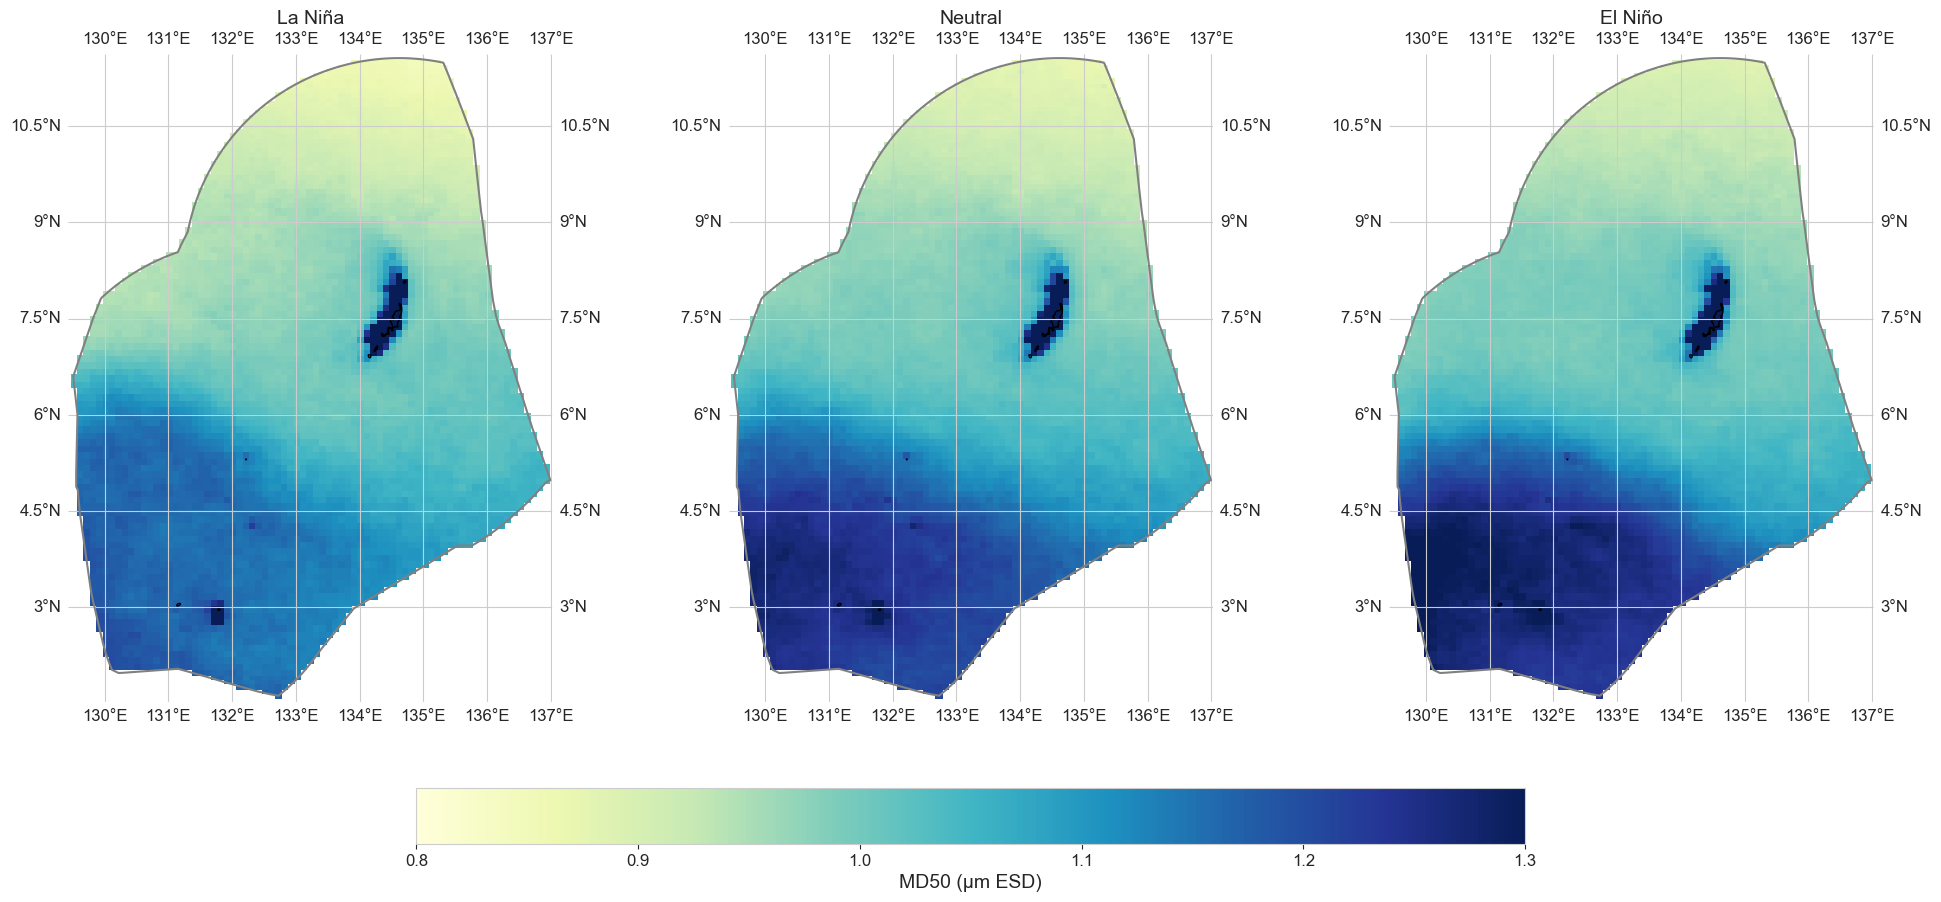

In [23]:
fig = plot_map_subplots(data_oni, dataset_id, shp_eez = shp_eez, cmap = 'YlGnBu', vmin = 0.8, vmax = 1.3, 
                  sub_plot= [1, 3], figsize = (20, 9),  cbar = True, cbar_pad = 0.1,
                  titles = ['La Niña', 'Neutral', 'El Niño'],)
plt.savefig(op.join(path_figs, 'F16_phytoplankton_ENSO.png'), dpi=300, bbox_inches='tight')


#### Anomaly

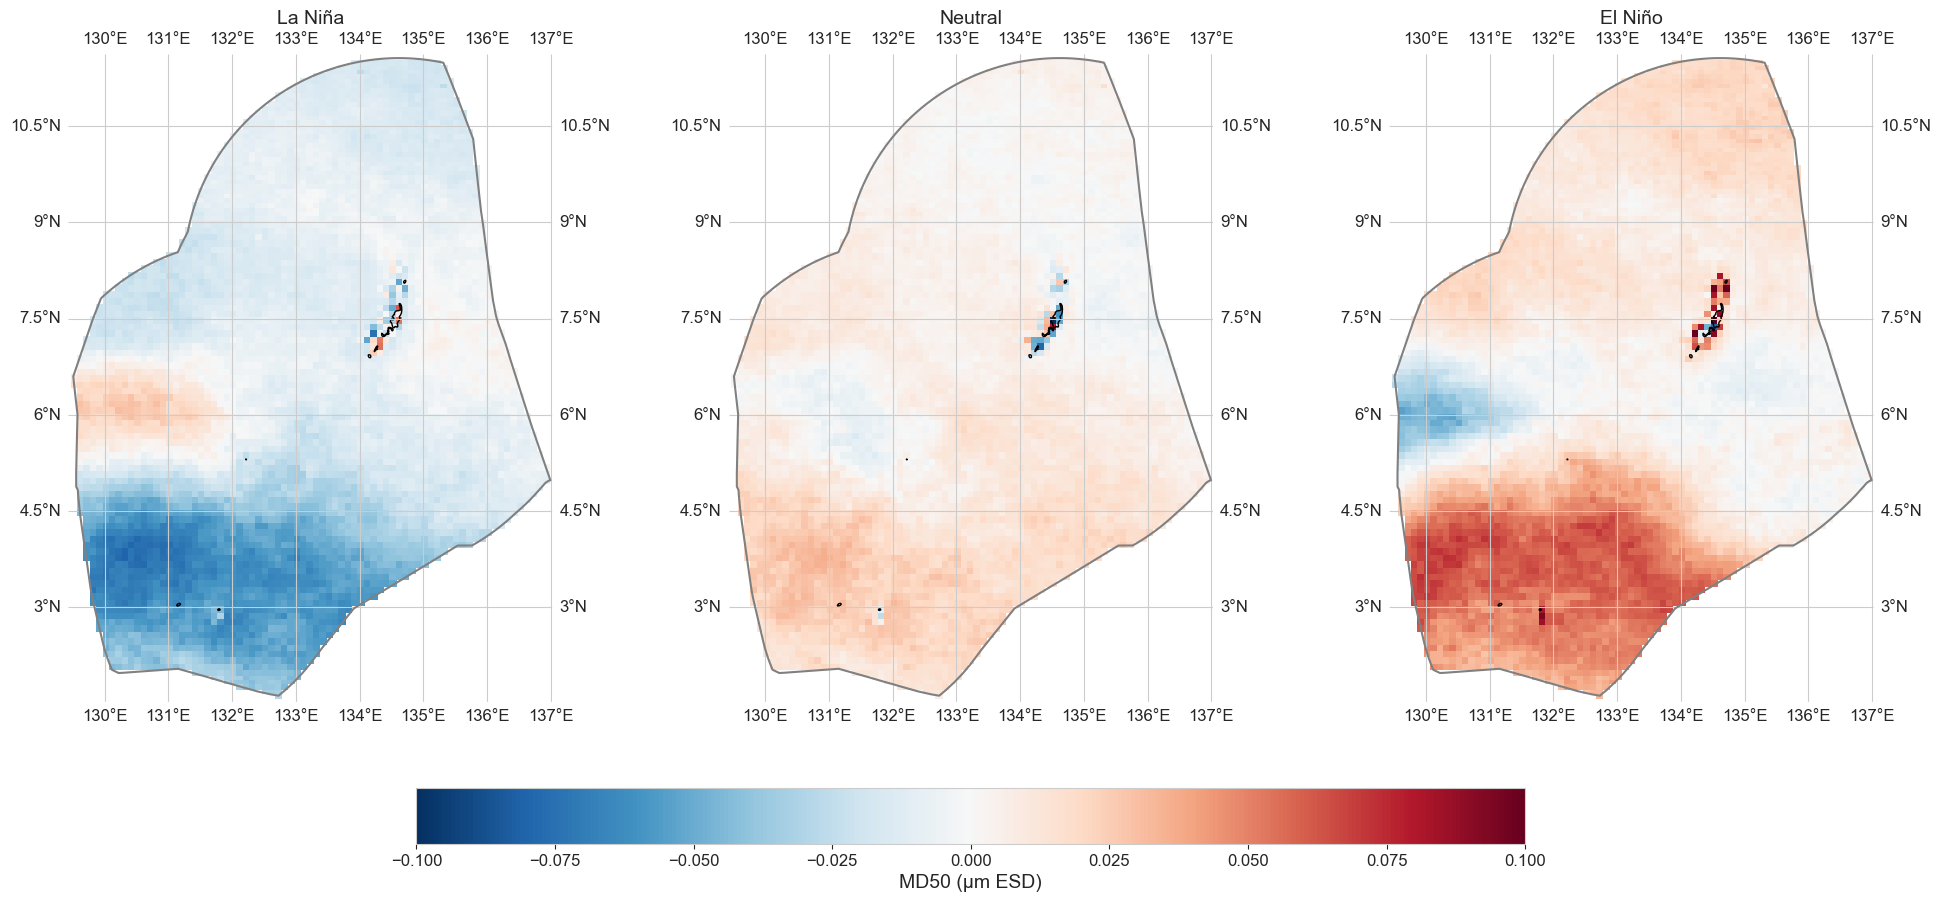

In [24]:
data_an = data_oni - data_xr.mean(dim='time')
fig = plot_map_subplots(data_an, dataset_id, shp_eez = shp_eez, cmap='RdBu_r', vmin=-.1, vmax=.1,
                  sub_plot= [1, 3], figsize = (20, 9),  cbar = True, cbar_pad = 0.1,
                  titles = ['La Niña', 'Neutral', 'El Niño'],)

## Table

In [25]:
from ind_setup.tables import style_matrix, table_ocean
style_matrix(table_ocean(data_xr, trend[0], data_oni, dataset_id))

Metric,Value
Monthly Average,1.053
Monthly Maximum 01/02/2005,1.305
Monthly Minimum 01/09/1998,0.813
Maximum Annual Average,1.132
Minimum Annual Average,1.011
Rate of change [µm ESD/year],-0.001
Change between 1998 and 2024 [µm ESD],-0.026
,
Average La Niña MD50,1.035
Average El Niño MD50,1.073


## Interpretation and reproducibility notes

- Results apply to the configured station, site or EEZ and should not be generalized without checking spatial representativeness.
- Product resolution, depth, model or satellite origin and temporal coverage differ among biogeochemical variables and must be considered in comparisons.
- Linear trends are descriptive unless the notebook explicitly accounts for temporal autocorrelation and other statistical assumptions.
- Confirm the printed source, analysis period, reference period and output paths before using figures or tables in reporting.